# 06 — Modelo final (notebook reducido de entrega)

**Este es el notebook definitivo** del proyecto: reproduce el pipeline ganador y genera `submission.csv` para Kaggle.

Tras la exploración en los notebooks `00`–`05` y el CLI (`train`, `tune`, `design`, …), el modelo elegido es **`lgbm_regressor`**: regresión ordinal sobre `sii` (0–3) con umbrales optimizados y métrica **QWK**.

Inspirado en notebooks *reduced* de competencias (p. ej. [1st place CMI v4.1.1](https://www.kaggle.com/code/)): una sola ruta lineal desde datos → modelo final → predicción.

**Requisitos:** `data/raw/train.csv` y `data/raw/test.csv` (Kaggle). Opcional: artefactos en `experiments/results/` del repo para reproducir exactamente las mismas cifras del informe.


In [1]:
# --- Configuracion (modelo ganador tras tuning) ---
SEED = 42
WINNING_MODEL = "lgbm_regressor"
MERGE_CLASSES_23 = False  # design: 4 clases > fusion 2+3

BEST_PARAMS = {
    "model__regressor__learning_rate": 0.031430022688291114,
    "model__regressor__min_child_samples": 7,
    "model__regressor__n_estimators": 249,
    "model__regressor__num_leaves": 17,
}

FORCE_REFIT = False   # True: reentrena aunque exista final_model.joblib
RUN_OOF_REPORT = False  # True: OOF 10-fold honesto (~5-15 min)
WRITE_MINIMAL_ARTIFACTS = True  # Crea JSON/CSV minimos si faltan


In [2]:
%run init_notebook.py


Project root: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica
Train data:   C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\data\raw\train.csv


In [3]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from src.config import CHECKPOINTS_DIR, CV_FOLDS, TEST_CSV_PATH, TRAIN_CSV_PATH
from src.data.dataset import load_modeling_frame
from src.evaluation.oof_report import run_oof_report
from src.evaluation.predict import run_predict
from src.training.fit_final import run_fit_final


def ensure_minimal_artifacts() -> None:
    """Pin winning model metadata when CLI was not run (solo train/test en data/raw)."""
    if not WRITE_MINIMAL_ARTIFACTS:
        return
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    cv_path = RESULTS_DIR / "all_models_cv.csv"
    if not cv_path.exists():
        pd.DataFrame(
            [{"model": WINNING_MODEL, "qwk_mean": 0.413, "qwk_std": 0.047}]
        ).to_csv(cv_path, index=False)
        print(f"Created stub: {cv_path}")

    tune_path = RESULTS_DIR / "tuning_best_params.json"
    if not tune_path.exists():
        payload = {
            "model": WINNING_MODEL,
            "best_params": BEST_PARAMS,
            "best_qwk_cv": 0.422,
        }
        tune_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
        print(f"Created: {tune_path}")

    design_path = RESULTS_DIR / "design_merge_classes_23.csv"
    if not design_path.exists():
        pd.DataFrame(
            [
                {"variant": "four_classes", "qwk": 0.426},
                {"variant": "merge_classes_23", "qwk": 0.411},
            ]
        ).to_csv(design_path, index=False)
        print(f"Created: {design_path}")


for p in (TRAIN_CSV_PATH, TEST_CSV_PATH):
    if not p.exists():
        raise FileNotFoundError(f"Missing {p} — download from Kaggle.")

ensure_minimal_artifacts()
print(f"Train: {TRAIN_CSV_PATH}")
print(f"Test:  {TEST_CSV_PATH}")


Train: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\data\raw\train.csv
Test:  C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\data\raw\test.csv


## 1. Datos y preprocesamiento


In [4]:
df_model = load_modeling_frame(apply_selection=False)
print(f"Modeling frame: {df_model.shape}")
print(df_model["sii"].value_counts().sort_index())
print(f"CV folds (config): {CV_FOLDS}")


Modeling frame: (2736, 46)
sii
0.0    1594
1.0     730
2.0     378
3.0      34
Name: count, dtype: int64
CV folds (config): 10


## 2. Decisiones del estudio (resumen)

| Decision | Eleccion |
|----------|----------|
| Target | `sii` ordinal 0–3 |
| Enfoque | Regresion ordinal + umbrales (no clasificador directo 4 clases) |
| Modelo | `lgbm_regressor` (mejor QWK en CV 10-fold) |
| Clases | 4 clases (no fusionar 2+3) |
| Metrica informe | QWK OOF (`report-oof`) |

Detalle exploratorio: notebooks `00`–`05` y `docs/informe_contenido_es.md`.


In [5]:
tune = json.loads((RESULTS_DIR / "tuning_best_params.json").read_text(encoding="utf-8"))
design = pd.read_csv(RESULTS_DIR / "design_merge_classes_23.csv")
cv = pd.read_csv(RESULTS_DIR / "all_models_cv.csv").sort_values("qwk_mean", ascending=False)

print("Top 5 modelos (CV):")
display(cv.head())
print(f"\nModelo final: {tune['model']}")
print(f"Hiperparametros: {tune['best_params']}")
print("\nDiseno 4 vs merge 2+3:")
display(design)


Top 5 modelos (CV):


,model,level,qwk_mean,qwk_std,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,balanced_accuracy_std
13,lgbm_regressor,advanced,0.413265,0.046993,0.357800,0.040897,0.358158,0.033372
10,xgb_regressor,advanced,0.399136,0.045243,0.380477,0.059048,0.372593,0.043948
6,svm,intermediate,0.393716,0.053510,0.382022,0.031418,0.428398,0.054426
3,random_forest,intermediate,0.393486,0.072483,0.352136,0.023058,0.358291,0.027348
12,regression_vote,advanced,0.382475,0.000000,0.324915,0.000000,0.330619,0.000000



Modelo final: lgbm_regressor
Hiperparametros: {'model__regressor__learning_rate': 0.031430022688291114, 'model__regressor__min_child_samples': 7, 'model__regressor__n_estimators': 249, 'model__regressor__num_leaves': 17}

Diseno 4 vs merge 2+3:


,variant,model,f1_macro,balanced_accuracy,qwk,accuracy
0,four_classes,lgbm_regressor,0.363416,0.366861,0.425768,0.572993
1,merge_classes_23,lgbm_regressor,0.496372,0.499459,0.410541,0.572993


## 3. Entrenamiento del modelo final (full train)


In [6]:
model_path = CHECKPOINTS_DIR / "final_model.joblib"
if FORCE_REFIT or not model_path.exists():
    run_fit_final()
else:
    print(f"Using existing checkpoint: {model_path}")
    print("Set FORCE_REFIT=True to retrain.")

meta = json.loads((RESULTS_DIR / "final_model_meta.json").read_text(encoding="utf-8"))
print(meta)


Using existing checkpoint: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\experiments\checkpoints\final_model.joblib
Set FORCE_REFIT=True to retrain.
{'model': 'lgbm_regressor', 'best_params': {'model__regressor__learning_rate': 0.031430022688291114, 'model__regressor__min_child_samples': 7, 'model__regressor__n_estimators': 249, 'model__regressor__num_leaves': 17}, 'merged_classes_23': False, 'fit_on_full_train': True, 'feature_selection': True, 'thresholds': [0.9711177626411477, 1.5173510916816946, 2.15641662119112]}


## 4. Evaluacion OOF honesta (opcional)

Activa `RUN_OOF_REPORT = True` arriba. Genera matriz de confusion y metricas por clase sin leakage (10-fold OOF). Cifras del informe: `oof_report_summary.json`.


In [7]:
oof_summary_path = RESULTS_DIR / "oof_report_summary.json"
if RUN_OOF_REPORT:
    summary = run_oof_report()
    print(f"OOF QWK: {summary['oof_qwk']:.4f}")
elif oof_summary_path.exists():
    summary = json.loads(oof_summary_path.read_text(encoding="utf-8"))
    print(f"OOF QWK (cached): {summary['oof_qwk']:.4f}")
else:
    print("No OOF report. Run with RUN_OOF_REPORT=True or: python -m src.main report-oof")
    summary = None


OOF QWK (cached): 0.4333


## 5. Prediccion y submission Kaggle


In [8]:
submission_path = run_predict()
submission = pd.read_csv(submission_path)
print(submission["sii"].value_counts().sort_index())
submission.head(10)


Model: lgbm_regressor
Rows: 20
Class distribution: {0: 11, 1: 7, 2: 2}
Saved: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\experiments\results\submission.csv
sii
0    11
1     7
2     2
Name: count, dtype: int64


,id,sii
0,00008ff9,1
1,000fd460,0
2,00105258,0
3,00115b9f,0
4,0016bb22,1
5,001f3379,0
6,0038ba98,0
7,0068a485,0
8,0069fbed,2
9,0083e397,1


## 6. Figuras y metricas por clase


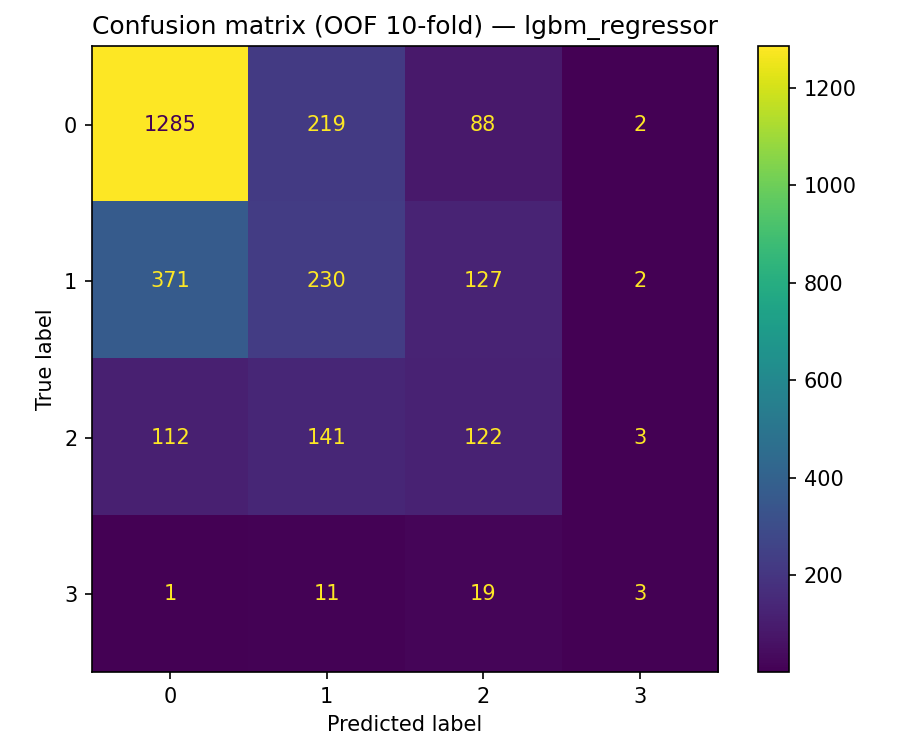

,class,precision,recall,f1,support
0,0,0.726399,0.806148,0.764199,1594
1,1,0.382696,0.315068,0.345605,730
2,2,0.342697,0.322751,0.332425,378
3,3,0.300000,0.088235,0.136364,34


Clase minoritaria 3: recall OOF 8.8% (support 34)
Ver docs/limitaciones_modelo.md


In [9]:
cm_path = FIGURES_DIR / "confusion_matrix_oof.png"
if cm_path.exists():
    display(Image(filename=str(cm_path)))
else:
    print(f"No figure: {cm_path} (run OOF report)")

per_class_path = RESULTS_DIR / "per_class_metrics_oof.csv"
if per_class_path.exists():
    display(pd.read_csv(per_class_path))

if summary and "limitations" in summary:
    lim = summary["limitations"]
    print(
        f"Clase minoritaria {lim['minority_class']}: "
        f"recall OOF {lim['minority_recall_oof']:.1%} "
        f"(support {lim['minority_support_oof']})"
    )
    print("Ver docs/limitaciones_modelo.md")


---

**Ruta de investigacion:** `00_introduccion` → `01_comprension` → `02_preparacion` → `03_modelado` → `04_mejoras_qwk` → `05_modelos_finales` → **este notebook (06)**.

**CLI equivalente:**
```
python -m src.main fit-final && python -m src.main report-oof && python -m src.main predict
```
